# 快速 PSD 调试

每次运行采集 Cell：采集 1s 数据 → 计算 Welch PSD → 叠加到同一张图中。
多次运行可对比 PSD，用于临时调试。采集期间自动关闭加热，采集后恢复。

## 可调参数

- `DAQ_DURATION`: 单次采集时长 (s)
- `NPERSEG`: Welch 每段点数
- `MAX_TRACES`: 图中最多保留的 PSD 曲线数

## 操作

1. 运行 **Cell 2**（环境准备），只运行一次
2. 反复运行 **Cell 4**（采集 + PSD），每次在图里叠加一条新曲线
3. 运行 **Cell 6** 清空图重新开始

<a id='env'></a>
## 环境准备（仅运行一次）

In [20]:
from pathlib import Path
import sys
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DAQConfig,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod, daq,
)
from scipy import signal as scipy_signal

# 加载配置
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ---------- 可调参数 ----------
DAQ_DURATION = 1.0         # 单次采集时长 (s)
DAQ_RATE = 100000          # 采样率 (Sa/s)
DAQ_TC = 7.85e-07          # 解调时间常数 (s)
DEMOD_ORDER = 4
SIGNAL_RANGE = 2.0         # 信号量程 (V)
OSC_FREQ = 90e3            # 振荡器频率 (Hz)
NPERSEG = 10000            # Welch 每段点数

SETTLE_TIME = 0.3          # 关闭加热后稳定等待时间 (s)
MAX_TRACES = 10            # 最大保留曲线数
# ------------------------------

# 设备连接（如果尚未连接）
if "devices" not in dir():
    devices = {}
    # HF2
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(host=hf2_cfg.get("host", "127.0.0.1"),
                        port=hf2_cfg.get("port", 8005),
                        api_level=1, device_id=hf2_cfg["device_id"])
    hfi.connect()
    hfi.set_extclk(True)
    devices["hf2"] = hfi
    print(f"HF2 已连接: {hfi.idn}")

    # 温度控制 DG4000
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    devices["dg_temp"] = dg_temp
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")

    # 配置 HF2 信号输入、振荡器、解调器
    demod.configure_signal_input(hfi, SignalInputConfig(
        input_index=0, range=SIGNAL_RANGE, ac_coupling=True,
        diff=False, impedance=50,
    ))
    demod.configure_oscillator(hfi, OscillatorConfig(
        osc_index=0, frequency=OSC_FREQ, source="manual",
    ))
    daq_demod_cfg = DemodulatorConfig(
        demod_index=0, enable=True, rate=DAQ_RATE,
        input_channel=0, osc_select=0, harmonic=1,
        time_constant=DAQ_TC, order=DEMOD_ORDER, phase=0.0,
    )
    actual_rate_daq = demod.configure_demodulator(hfi, daq_demod_cfg)
    time.sleep(0.2)
    print(f"解调器已配置: rate={actual_rate_daq:.0f} Sa/s, TC={DAQ_TC*1e6:.2f} μs")
else:
    hfi = devices["hf2"]
    dg_temp = devices["dg_temp"]
    print("设备已连接，跳过初始化")

# 初始化 PSD 存储列表
if "psd_store" not in dir():
    psd_store = []  # 每个元素: (freq_axis, psd, label)

print("环境准备完成。请运行下一个 Cell 开始采集。")

设备已连接，跳过初始化
环境准备完成。请运行下一个 Cell 开始采集。


## 采集 + 计算 PSD + 画图（反复运行此 Cell）


第 7 次采集
关闭加热...
采集中... (duration=1.0s, grid_cols=230263)
采集完成, 用时 1.9s, 波形长度 230263
恢复加热...
PSD 计算完成: 5001 频率点


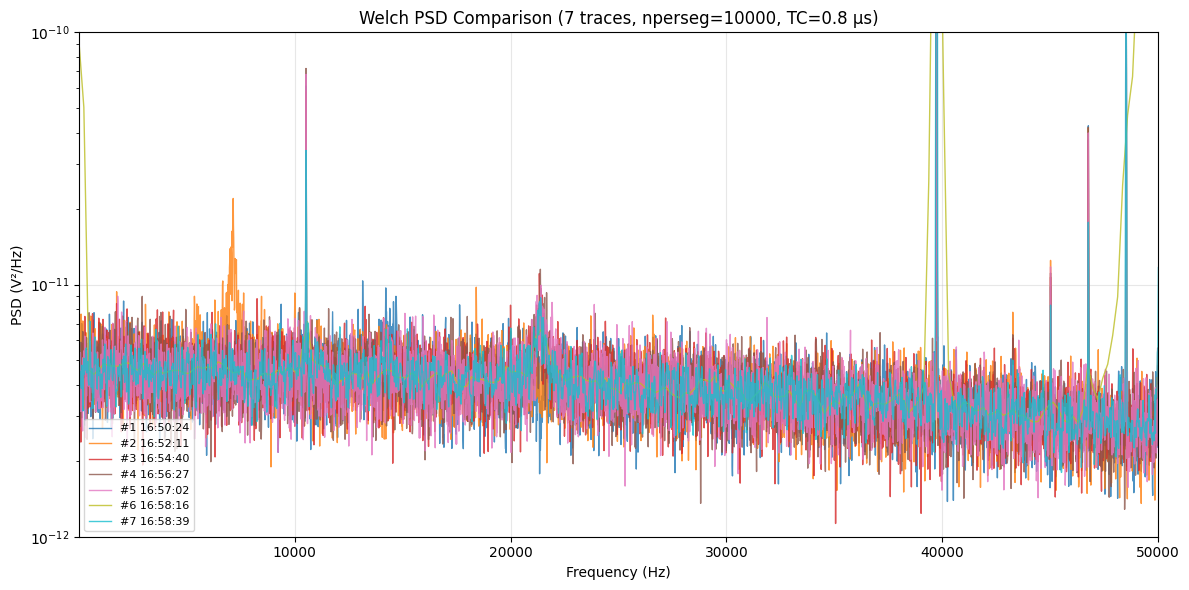


图中已叠加 7 条 PSD 曲线。如需清空重新开始，请运行下一个 Cell。


In [21]:
# ===== 单次采集 + PSD 计算 =====
run_idx = len(psd_store) + 1
print(f"\n{'='*50}")
print(f"第 {run_idx} 次采集")
print(f"{'='*50}")

# 1. 关闭加热
print("关闭加热...")
dg_temp.set_output(False, channel=2)
time.sleep(SETTLE_TIME)

# 2. HF2 DAQ 采集
grid_cols = int(actual_rate_daq * DAQ_DURATION)
daq_cfg = DAQConfig(
    device=MAPPING["lockin_r"]["device_id"],
    trigger_type=0,
    duration=DAQ_DURATION,
    grid_cols=grid_cols, grid_rows=1, grid_mode=2,
    signal_paths=["sample.y"],
)
print(f"采集中... (duration={DAQ_DURATION}s, grid_cols={grid_cols})")
t0 = time.time()
try:
    results = daq.acquire_data(
        hfi, daq_cfg, demod_idx=0,
        actual_rate=actual_rate_daq,
        timeout=DAQ_DURATION + 10.0,
    )
    waveform = results[0].values
    elapsed = time.time() - t0
    print(f"采集完成, 用时 {elapsed:.1f}s, 波形长度 {len(waveform)}")
except Exception as e:
    print(f"采集失败: {e}")
    dg_temp.set_output(True, channel=2)
    raise

# 3. 恢复加热
print("恢复加热...")
dg_temp.set_output(True, channel=2)

# 4. 计算 Welch PSD
if len(waveform) >= NPERSEG:
    f_psd, psd = scipy_signal.welch(
        waveform, fs=actual_rate_daq, nperseg=NPERSEG,
        noverlap=None, scaling="density",
    )
    ts_label = datetime.now().strftime("%H:%M:%S")
    label = f"#{run_idx} {ts_label}"
    psd_store.append((f_psd.copy(), psd.copy(), label))
    print(f"PSD 计算完成: {len(f_psd)} 频率点")
else:
    print(f"⚠️ 波形太短 ({len(waveform)} < {NPERSEG})，跳过 PSD")
    if len(psd_store) == 0:
        raise RuntimeError("没有有效 PSD 数据")

# 5. 限制存储数量
if len(psd_store) > MAX_TRACES:
    psd_store.pop(0)

# 6. 画图
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(psd_store)))

for idx, (f_arr, p_arr, lbl) in enumerate(psd_store):
    ax.plot(f_arr, p_arr, color=colors[idx], alpha=0.8, linewidth=1.0, label=lbl)

ax.set_xlim(1,50000)
ax.set_ylim(1e-12, 1e-10)
ax.set_yscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (V²/Hz)")
ax.set_title(f"Welch PSD Comparison ({len(psd_store)} traces, "
             f"nperseg={NPERSEG}, TC={DAQ_TC*1e6:.1f} μs)")
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\n图中已叠加 {len(psd_store)} 条 PSD 曲线。"
      f"如需清空重新开始，请运行下一个 Cell。")

## 清空历史数据，重新开始

In [10]:
# 清空所有历史 PSD
psd_store.clear()
print("✅ 已清空，下一次运行采集 Cell 将从 #1 开始。")

✅ 已清空，下一次运行采集 Cell 将从 #1 开始。
